---
|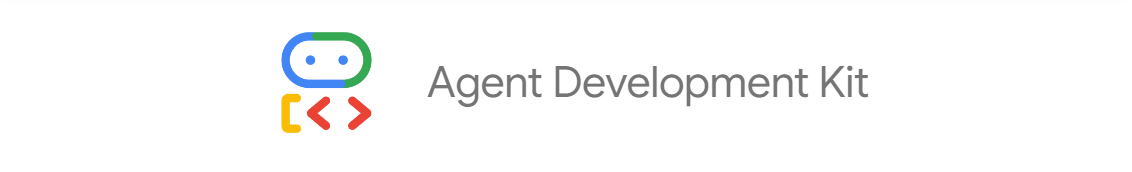|
---

---
## Customer Support (Travel) — Multi-Agent Demo for ADK Web
### This code defines a multi-agent system for a travel customer support scenario.
- Functions: check_order_status, lookup_product_info
- Agents: order_agent, product_agent, search_agent, root_agent
- Tools on root: AgentTool(search_agent), check_order_status
---

## `multi_agent_system`
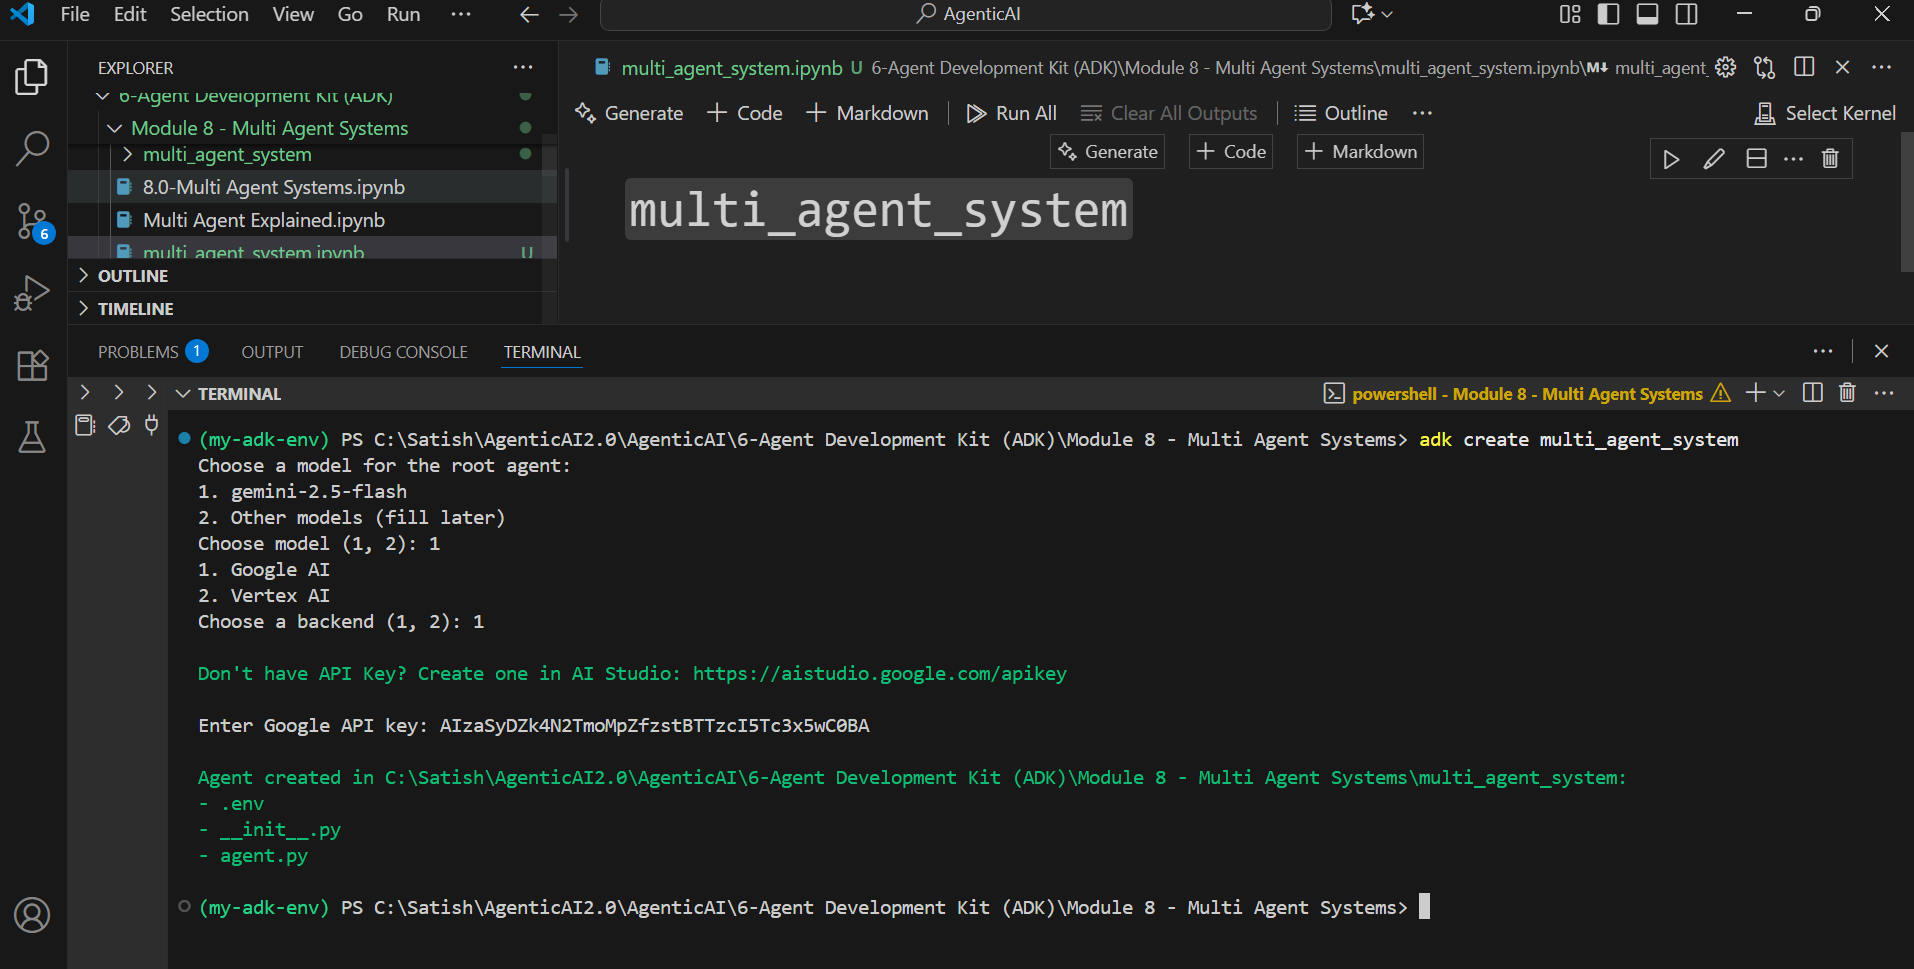
---
```Python
from google.adk.agents import Agent
from google.adk.tools import google_search
from google.adk.tools.agent_tool import AgentTool


def check_order_status(order_id: str) -> dict:
    """Return the status of a travel booking (PNR/reference).

    Input:
        order_id: booking reference (e.g., 'NYC123').

    Output (dict):
        {
            "order_id": str,
            "status": str,         # e.g., "Ticketed", "Awaiting Payment", "Completed", "Not Found"
            "pnr": str | None,     # booking PNR if ticketed
            "from": str | None,    # origin IATA code
            "to": str | None,      # destination IATA code
            "departure": str       # ISO date or "Unknown"
        }
    """
    print(f"[booking] checking status for: {order_id}")

    # Mock booking store for demo
    bookings = {
        "NYC123": {"status": "Ticketed", "pnr": "PNR789", "departure": "2025-09-15", "from": "JFK", "to": "LHR"},
        "DXB456": {"status": "Awaiting Payment", "pnr": None, "departure": "TBD", "from": "DXB", "to": "CDG"},
        "TYO777": {"status": "Completed", "pnr": "PNR321", "departure": "2025-08-30", "from": "HND", "to": "SFO"},
    }

    if order_id in bookings:
        info = {"order_id": order_id, **bookings[order_id]}
    else:
        info = {"order_id": order_id, "status": "Not Found", "pnr": None, "departure": "Unknown", "from": None, "to": None}

    # If you use callbacks, you can stash info into state there for later steps.
    return info


def lookup_product_info(product_name: str) -> dict:
    """Return destination/package details such as price, availability, seasons, and highlights.

    Input:
        product_name: destination or package name (e.g., 'Paris').

    Output (dict):
        {
            "name": str,
            "avg_price": str,     # display-friendly price range
            "availability": str,  # "Open", "Limited", "Seasonal", "Not Listed"
            "best_season": str,   # human-friendly season guidance
            "highlights": list    # short bullets of attractions or features
        }
    """
    print(f"[destination] looking up: {product_name}")

    # Mock catalog for demo
    catalog = {
        "bali":  {"avg_price": "$1,299", "availability": "Open",     "best_season": "Apr–Oct",            "highlights": ["Beaches", "Ubud rice terraces", "Waterfalls"]},
        "paris": {"avg_price": "$1,599", "availability": "Limited",  "best_season": "Apr–Jun, Sep–Oct",   "highlights": ["Louvre", "Eiffel Tower", "Cafés"]},
        "tokyo": {"avg_price": "$1,799", "availability": "Open",     "best_season": "Mar–May, Oct–Nov",   "highlights": ["Shinjuku", "Asakusa", "Sushi tours"]},
        "alps":  {"avg_price": "$1,499", "availability": "Seasonal", "best_season": "Dec–Mar",            "highlights": ["Skiing", "Scenic trains", "Fondue"]},
    }

    key = product_name.lower().strip()
    if key in catalog:
        base = catalog[key]
        info = {"name": product_name, **base}
    else:
        info = {"name": product_name, "avg_price": "Unknown", "availability": "Not Listed", "best_season": "Varies", "highlights": []}

    return info


# -------------------------- Specialist Agents ------------------------------

# Booking specialist (keeps your original agent name)
order_agent = Agent(
    name="order_agent",
    model="gemini-2.0-flash",
    description="I handle all booking-related inquiries and tracking.",  # clear description helps routing
    instruction="""
You are a travel booking specialist. When customers ask about bookings:

1) Use check_order_status to retrieve booking info (status, PNR, route, date).
2) Give clear updates and next steps (payment, documents, recheck time).
3) If ticketed, share PNR and departure. If pending, explain what is needed.

Be friendly and precise.
Example: "Your booking NYC123 is ticketed. PNR PNR789 for JFK → LHR on 2025-09-15."

After you answer, return control to the customer service manager.
""",
    tools=[check_order_status],
)

# Destination/package specialist (keeps your original agent name)
product_agent = Agent(
    name="product_agent",
    model="gemini-2.0-flash",
    description="I help with destination or package information and availability.",  # clear description helps routing
    instruction="""
You are a destination/package specialist. When customers ask about travel options:

1) Use lookup_product_info to fetch details.
2) Share price range, availability, best seasons, and highlights.
3) Suggest nearby or similar options when availability is limited.

Be helpful and travel-savvy.
Example: "Paris is about $1,599 and availability is limited. Best seasons: Apr–Jun or Sep–Oct. Highlights include the Louvre and Eiffel Tower."
When you are done, hand control back to the manager.
""",
    tools=[lookup_product_info],
)

# General info/search agent (keeps your original agent name and search tool)
search_agent = Agent(
    name="search_agent",
    model="gemini-2.0-flash",
    description="I help with general travel questions and quick lookups.",
    instruction="""
You are a general travel support specialist. For broad questions:

1) Provide clear guidance (baggage policy basics, visa notes, airport tips).
2) Use web search when current information is required.
3) If unsure, recommend checking official sources.

Example: "Carry-on limits vary by airline. Share the airline name and I can check current rules."
""",
    tools=[google_search],
)

# ---------------------------- Root Manager --------------------------------
root_agent = Agent(
    name="customer_service_manager",
    model="gemini-2.0-flash",
    description="I'm the travel service manager who coordinates all inquiries.",
    instruction="""
You are a travel service manager. Route customer requests to the right specialist:

- Booking questions (PNR, status, dates): call the check_order_status tool.
- Destination/package questions (price, availability, highlights): delegate to product_agent.
- General travel questions (policies, news): call search_agent via AgentTool.

Be professional and ensure each answer is complete and accurate.
""",
    sub_agents=[product_agent],
    tools=[AgentTool(search_agent), check_order_status],
)
```
---